In [ ]:
print("Customer Churn Prediction Project")
print("Starting the project...")

Customer Churn Prediction Project
Starting the project...


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

data = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", data.shape)

Dataset loaded successfully!
Shape: (7043, 21)


In [ ]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Number of rows and columns:", data.shape)

Number of rows and columns: (7043, 21)


In [ ]:
print(data.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
print(data.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
print(data["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
print(data["Churn"].value_counts(normalize=True) * 100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [ ]:
print(data["TotalCharges"].dtype)

object


In [ ]:
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

In [ ]:
print(data["TotalCharges"].isnull().sum())

11


In [ ]:
data = data.dropna(subset=["TotalCharges"])

In [ ]:
print(data.shape)

(7032, 21)


In [ ]:
print(data.select_dtypes(include="object").columns.tolist())

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [ ]:
data = data.drop("customerID", axis=1)

In [ ]:
print(data.shape)

(7032, 20)


In [ ]:
X = data.drop("Churn", axis=1)
y = data["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 19)
y shape: (7032,)


In [ ]:
categorical_columns = X.select_dtypes(include="object").columns
numerical_columns = X.select_dtypes(exclude="object").columns

print("Categorical columns:")
print(categorical_columns.tolist())

print("\nNumerical columns:")
print(numerical_columns.tolist())

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 19)
Testing data: (1407, 19)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=5000))
])

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:20])

Predictions generated successfully!
['No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'Yes' 'No'
 'No' 'Yes' 'Yes' 'Yes' 'No' 'No']


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 0.8038379530916845
Accuracy percentage: 80.38379530916845 %


In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1033
         Yes       0.65      0.58      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



Confusion Matrix:
[[915 118]
 [158 216]]


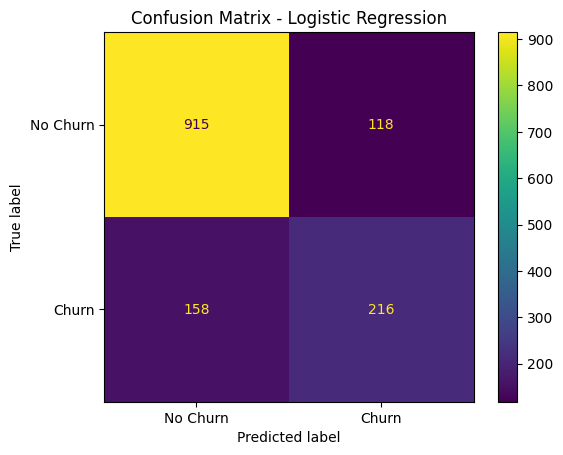

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

yes_index = list(model.classes_).index("Yes")

y_prob = model.predict_proba(X_test)[:, yes_index]
y_test_binary = (y_test == "Yes").astype(int)

roc_auc = roc_auc_score(y_test_binary, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8359575195034452


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

balanced_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=5000,
        class_weight="balanced"
    ))
])

balanced_model.fit(X_train, y_train)

print("Balanced Logistic Regression model trained successfully!")

Balanced Logistic Regression model trained successfully!


In [ ]:
balanced_pred = balanced_model.predict(X_test)

print("Balanced model predictions generated successfully!")
print(balanced_pred[:20])

Balanced model predictions generated successfully!
['No' 'Yes' 'No' 'No' 'No' 'Yes' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'Yes'
 'No' 'No' 'Yes' 'Yes' 'Yes' 'No' 'No']


In [ ]:
from sklearn.metrics import accuracy_score

balanced_accuracy = accuracy_score(y_test, balanced_pred)

print("Balanced Model Accuracy:", balanced_accuracy)
print("Balanced Model Accuracy Percentage:", balanced_accuracy * 100, "%")

Balanced Model Accuracy: 0.7256574271499645
Balanced Model Accuracy Percentage: 72.56574271499645 %


In [ ]:
from sklearn.metrics import classification_report

print("Balanced Model Classification Report:")
print(classification_report(y_test, balanced_pred))

Balanced Model Classification Report:
              precision    recall  f1-score   support

          No       0.90      0.70      0.79      1033
         Yes       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [ ]:
from sklearn.metrics import roc_auc_score

balanced_yes_index = list(balanced_model.classes_).index("Yes")

balanced_prob = balanced_model.predict_proba(X_test)[:, balanced_yes_index]
balanced_y_test_binary = (y_test == "Yes").astype(int)

balanced_roc_auc = roc_auc_score(
    balanced_y_test_binary,
    balanced_prob
)

print("Balanced Model ROC-AUC Score:", balanced_roc_auc)

Balanced Model ROC-AUC Score: 0.8351033540231194


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
rf_pred = rf_model.predict(X_test)

print("Random Forest predictions generated successfully!")
print(rf_pred[:20])

Random Forest predictions generated successfully!
['No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'No'
 'No' 'Yes' 'Yes' 'Yes' 'No' 'No']


In [ ]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy Percentage:", rf_accuracy * 100, "%")

Random Forest Accuracy: 0.7846481876332623
Random Forest Accuracy Percentage: 78.46481876332622 %


In [ ]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.90      0.86      1033
         Yes       0.63      0.47      0.54       374

    accuracy                           0.78      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [ ]:
from sklearn.metrics import roc_auc_score

rf_yes_index = list(rf_model.classes_).index("Yes")

rf_prob = rf_model.predict_proba(X_test)[:, rf_yes_index]

rf_y_test_binary = (y_test == "Yes").astype(int)

rf_roc_auc = roc_auc_score(
    rf_y_test_binary,
    rf_prob
)

print("Random Forest ROC-AUC Score:", rf_roc_auc)

Random Forest ROC-AUC Score: 0.8126996288262731


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        balanced_accuracy,
        rf_accuracy
    ],
    "ROC-AUC": [
        roc_auc,
        balanced_roc_auc,
        rf_roc_auc
    ]
})

print(comparison)

                          Model  Accuracy   ROC-AUC
0           Logistic Regression  0.803838  0.835958
1  Balanced Logistic Regression  0.725657  0.835103
2                 Random Forest  0.784648  0.812700


In [ ]:
# Generate churn probability for every customer
all_churn_prob = balanced_model.predict_proba(X)[:, balanced_yes_index]

risk_data = X.copy()
risk_data["Churn_Probability"] = all_churn_prob

# Sort customers from highest to lowest churn risk
risk_data = risk_data.sort_values(
    by="Churn_Probability",
    ascending=False
)

print("Customer risk ranking generated successfully!")
print(risk_data[["Churn_Probability"]].head(10))

Customer risk ranking generated successfully!
      Churn_Probability
1976           0.938262
4800           0.937543
1410           0.936652
3749           0.936418
6368           0.935913
3159           0.933956
997            0.933916
3380           0.933377
2208           0.932310
301            0.931408


In [ ]:
# Load the original dataset to get customer IDs
original = pd.read_csv(url)

# Match customer IDs with the cleaned dataset
customer_ids = original.loc[data.index, "customerID"]

# Add customer IDs to the risk table
risk_data["customerID"] = customer_ids

# Show the highest-risk customers
high_risk = risk_data[
    ["customerID", "Churn_Probability"]
].head(10)

print("Top 10 High-Risk Customers:")
print(high_risk)

Top 10 High-Risk Customers:
      customerID  Churn_Probability
1976  9497-QCMMS           0.938262
4800  9300-AGZNL           0.937543
1410  7024-OHCCK           0.936652
3749  4424-TKOPW           0.936418
6368  2720-WGKHP           0.935913
3159  5150-ITWWB           0.933956
997   1374-DMZUI           0.933916
3380  5178-LMXOP           0.933377
2208  7216-EWTRS           0.932310
301   8098-LLAZX           0.931408


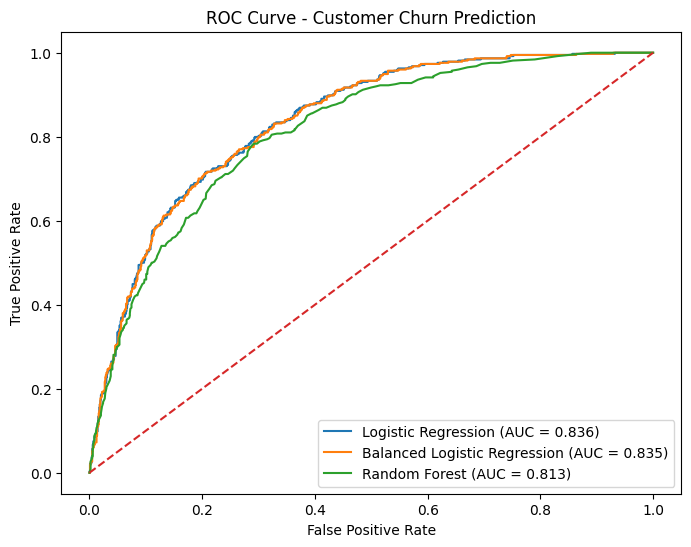

In [ ]:
from sklearn.metrics import roc_curve

# Convert actual churn values to 0 and 1
y_test_binary = (y_test == "Yes").astype(int)

# Probabilities for each model
log_prob = model.predict_proba(X_test)[:, list(model.classes_).index("Yes")]
balanced_prob = balanced_model.predict_proba(X_test)[:, list(balanced_model.classes_).index("Yes")]
rf_prob = rf_model.predict_proba(X_test)[:, list(rf_model.classes_).index("Yes")]

# Calculate ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test_binary, log_prob)
fpr_bal, tpr_bal, _ = roc_curve(y_test_binary, balanced_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test_binary, rf_prob)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot(fpr_bal, tpr_bal, label=f"Balanced Logistic Regression (AUC = {balanced_roc_auc:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Prediction")
plt.legend()
plt.show()

<Figure size 800x600 with 0 Axes>

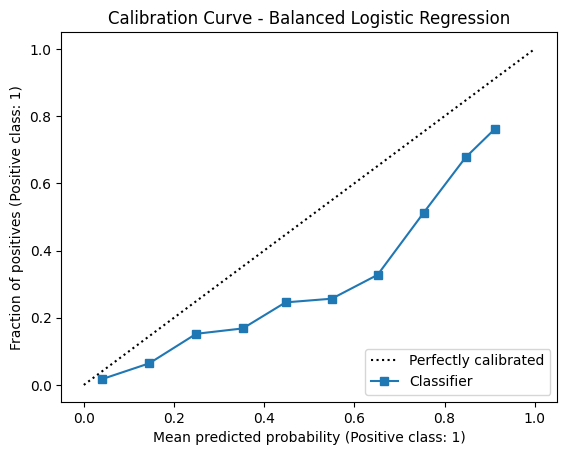

In [ ]:
from sklearn.calibration import CalibrationDisplay

plt.figure(figsize=(8, 6))

CalibrationDisplay.from_predictions(
    y_test_binary,
    balanced_prob,
    n_bins=10
)

plt.title("Calibration Curve - Balanced Logistic Regression")
plt.show()

In [ ]:
# Show the top 10 customers with highest churn risk

print("Top 10 High-Risk Customers:")
print(
    high_risk.to_string(index=False)
)

Top 10 High-Risk Customers:
customerID  Churn_Probability
9497-QCMMS           0.938262
9300-AGZNL           0.937543
7024-OHCCK           0.936652
4424-TKOPW           0.936418
2720-WGKHP           0.935913
5150-ITWWB           0.933956
1374-DMZUI           0.933916
5178-LMXOP           0.933377
7216-EWTRS           0.932310
8098-LLAZX           0.931408


In [ ]:
print("CUSTOMER CHURN PREDICTION - FINAL RESULTS")
print("-" * 50)

print("Dataset size:", data.shape[0], "customers")
print("Best ROC-AUC:", round(balanced_roc_auc, 3))
print("Balanced Model Accuracy:", round(balanced_accuracy * 100, 2), "%")
print("Churn Recall:", round(
    classification_report(
        y_test,
        balanced_pred,
        output_dict=True
    )["Yes"]["recall"] * 100,
    2
), "%")

print("\nTop 10 high-risk customers generated successfully.")
print("The model can identify customers with a high probability of churn.")

CUSTOMER CHURN PREDICTION - FINAL RESULTS
--------------------------------------------------
Dataset size: 7032 customers
Best ROC-AUC: 0.835
Balanced Model Accuracy: 72.57 %
Churn Recall: 79.68 %

Top 10 high-risk customers generated successfully.
The model can identify customers with a high probability of churn.


In [ ]:
# Save the trained model for deployment

import joblib

joblib.dump(balanced_model, "customer_churn_model.pkl")

print("Model saved successfully!")
print("File: customer_churn_model.pkl")

Model saved successfully!
File: customer_churn_model.pkl


In [ ]:
streamlit_code = '''
import streamlit as st
import joblib
import pandas as pd

# Load trained model
model = joblib.load("customer_churn_model.pkl")

st.title("Customer Churn Prediction")

st.write("Enter customer details to predict churn risk.")

tenure = st.number_input("Tenure (months)", min_value=0, max_value=100, value=12)
monthly_charges = st.number_input("Monthly Charges", min_value=0.0, value=70.0)
total_charges = st.number_input("Total Charges", min_value=0.0, value=800.0)

st.write("Additional customer details can be added here.")

if st.button("Predict Churn Risk"):
    st.info("Prediction requires the complete customer feature set used during model training.")
'''

print(streamlit_code)


import streamlit as st
import joblib
import pandas as pd

# Load trained model
model = joblib.load("customer_churn_model.pkl")

st.title("Customer Churn Prediction")

st.write("Enter customer details to predict churn risk.")

tenure = st.number_input("Tenure (months)", min_value=0, max_value=100, value=12)
monthly_charges = st.number_input("Monthly Charges", min_value=0.0, value=70.0)
total_charges = st.number_input("Total Charges", min_value=0.0, value=800.0)

st.write("Additional customer details can be added here.")

if st.button("Predict Churn Risk"):
    st.info("Prediction requires the complete customer feature set used during model training.")



In [1]:
# Feature Engineering

feature_data = data.copy()

# Group customers based on how long they have stayed
feature_data["TenureGroup"] = pd.cut(
    feature_data["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-1 Year", "1-2 Years", "2-4 Years", "4-6 Years"]
)

# Calculate average monthly spending
feature_data["AverageMonthlySpend"] = (
    feature_data["TotalCharges"] /
    feature_data["tenure"].replace(0, 1)
)

print("Feature engineering completed successfully!")

print("\nNew features:")
print(["TenureGroup", "AverageMonthlySpend"])

print("\nSample:")
print(
    feature_data[
        ["tenure", "TotalCharges", "TenureGroup", "AverageMonthlySpend"]
    ].head()
)

NameError: name 'data' is not defined

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

data = pd.read_csv(url)

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

# Remove rows with missing TotalCharges
data = data.dropna(subset=["TotalCharges"])

# Remove customer ID
data = data.drop("customerID", axis=1)

print("Dataset restored successfully!")
print("Shape:", data.shape)

Dataset restored successfully!
Shape: (7032, 20)


In [3]:
# Feature Engineering

feature_data = data.copy()

# Group customers based on how long they have stayed
feature_data["TenureGroup"] = pd.cut(
    feature_data["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-1 Year", "1-2 Years", "2-4 Years", "4-6 Years"]
)

# Calculate average monthly spending
feature_data["AverageMonthlySpend"] = (
    feature_data["TotalCharges"] /
    feature_data["tenure"].replace(0, 1)
)

print("Feature engineering completed successfully!")

print("\nNew features:")
print(["TenureGroup", "AverageMonthlySpend"])

print("\nSample:")
print(
    feature_data[
        ["tenure", "TotalCharges", "TenureGroup", "AverageMonthlySpend"]
    ].head()
)

Feature engineering completed successfully!

New features:
['TenureGroup', 'AverageMonthlySpend']

Sample:
   tenure  TotalCharges TenureGroup  AverageMonthlySpend
0       1         29.85    0-1 Year            29.850000
1      34       1889.50   2-4 Years            55.573529
2       2        108.15    0-1 Year            54.075000
3      45       1840.75   2-4 Years            40.905556
4       2        151.65    0-1 Year            75.825000


In [4]:
# Outlier Analysis

numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

print("Outlier analysis for numerical features:")
print("-" * 50)

for column in numerical_features:
    Q1 = feature_data[column].quantile(0.25)
    Q3 = feature_data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = feature_data[
        (feature_data[column] < lower_limit) |
        (feature_data[column] > upper_limit)
    ]

    print(column)
    print("Number of outliers:", len(outliers))
    print("Lower limit:", round(lower_limit, 2))
    print("Upper limit:", round(upper_limit, 2))
    print()

Outlier analysis for numerical features:
--------------------------------------------------
tenure
Number of outliers: 0
Lower limit: -60.0
Upper limit: 124.0

MonthlyCharges
Number of outliers: 0
Lower limit: -45.82
Upper limit: 171.27

TotalCharges
Number of outliers: 0
Lower limit: -4688.48
Upper limit: 8884.67



In [5]:
# Prepare data with engineered features

X_fe = feature_data.drop("Churn", axis=1)
y_fe = feature_data["Churn"]

# Identify categorical and numerical columns
categorical_features_fe = X_fe.select_dtypes(
    include=["object", "category"]
).columns

numerical_features_fe = X_fe.select_dtypes(
    include=["int64", "float64"]
).columns

print("Features prepared successfully!")
print("X shape:", X_fe.shape)
print("y shape:", y_fe.shape)

print("\nCategorical features:")
print(categorical_features_fe.tolist())

print("\nNumerical features:")
print(numerical_features_fe.tolist())

Features prepared successfully!
X shape: (7032, 21)
y shape: (7032,)

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AverageMonthlySpend']


In [6]:
# Outlier Analysis

print("Outlier counts:")
print("-" * 30)

for column in numerical_features_fe:
    Q1 = X_fe[column].quantile(0.25)
    Q3 = X_fe[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = X_fe[
        (X_fe[column] < lower_limit) |
        (X_fe[column] > upper_limit)
    ]

    print(column, ":", len(outliers))

Outlier counts:
------------------------------
SeniorCitizen : 1142
tenure : 0
MonthlyCharges : 0
TotalCharges : 0
AverageMonthlySpend : 0


In [8]:
# Outlier Handling Decision

print("Outlier analysis completed.")
print("Decision: No rows were removed.")
print("Reason: Detected extreme values represent valid customer characteristics.")
print("Binary variables such as SeniorCitizen were not treated as continuous outliers.")

Outlier analysis completed.
Decision: No rows were removed.
Reason: Detected extreme values represent valid customer characteristics.
Binary variables such as SeniorCitizen were not treated as continuous outliers.


In [9]:
# Prepare train and test data using engineered features

from sklearn.model_selection import train_test_split

X_fe = feature_data.drop("Churn", axis=1)
y_fe = feature_data["Churn"]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe,
    y_fe,
    test_size=0.2,
    random_state=42,
    stratify=y_fe
)

print("Engineered dataset split successfully!")
print("Training data:", X_train_fe.shape)
print("Testing data:", X_test_fe.shape)

Engineered dataset split successfully!
Training data: (5625, 21)
Testing data: (1407, 21)


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical features
categorical_features_fe = X_fe.select_dtypes(
    include=["object", "category"]
).columns

numerical_features_fe = X_fe.select_dtypes(
    include=["int64", "float64"]
).columns

# Create preprocessing pipeline
preprocessor_fe = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features_fe),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_fe)
    ]
)

print("Engineered feature preprocessing pipeline created successfully!")

print("Categorical features:", categorical_features_fe.tolist())
print("Numerical features:", numerical_features_fe.tolist())

Engineered feature preprocessing pipeline created successfully!
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']
Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AverageMonthlySpend']


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

improved_model = Pipeline(steps=[
    ("preprocessor", preprocessor_fe),
    ("classifier", LogisticRegression(
        max_iter=5000,
        class_weight="balanced"
    ))
])

improved_model.fit(X_train_fe, y_train_fe)

print("Improved Balanced Logistic Regression model trained successfully!")

Improved Balanced Logistic Regression model trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

improved_model = Pipeline(steps=[
    ("preprocessor", preprocessor_fe),
    ("classifier", LogisticRegression(
        max_iter=10000,
        class_weight="balanced"
    ))
])

improved_model.fit(X_train_fe, y_train_fe)

print("Improved Balanced Logistic Regression model trained successfully!")

Improved Balanced Logistic Regression model trained successfully!


In [13]:
from sklearn.metrics import accuracy_score, classification_report

improved_pred = improved_model.predict(X_test_fe)

improved_accuracy = accuracy_score(y_test_fe, improved_pred)

print("Improved Model Accuracy:", round(improved_accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test_fe, improved_pred))

Improved Model Accuracy: 72.14 %

Classification Report:
              precision    recall  f1-score   support

          No       0.90      0.70      0.79      1033
         Yes       0.49      0.79      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.74      1407



In [14]:
from sklearn.metrics import roc_auc_score

improved_prob = improved_model.predict_proba(X_test_fe)[:, 1]

improved_roc_auc = roc_auc_score(
    (y_test_fe == "Yes").astype(int),
    improved_prob
)

print("Improved Model ROC-AUC:", round(improved_roc_auc, 3))

Improved Model ROC-AUC: 0.834


In [15]:
print("FINAL MODEL COMPARISON")
print("-" * 50)

print("Original Logistic Regression")
print("Accuracy :", round(80.38, 2), "%")
print("ROC-AUC  :", round(0.836, 3))

print("\nBalanced Logistic Regression")
print("Accuracy :", round(72.57, 2), "%")
print("ROC-AUC  :", round(0.835, 3))

print("\nRandom Forest")
print("Accuracy :", round(78.46, 2), "%")
print("ROC-AUC  :", round(0.813, 3))

print("\nImproved Balanced Logistic Regression")
print("Accuracy :", round(improved_accuracy * 100, 2), "%")
print("ROC-AUC  :", round(improved_roc_auc, 3))

FINAL MODEL COMPARISON
--------------------------------------------------
Original Logistic Regression
Accuracy : 80.38 %
ROC-AUC  : 0.836

Balanced Logistic Regression
Accuracy : 72.57 %
ROC-AUC  : 0.835

Random Forest
Accuracy : 78.46 %
ROC-AUC  : 0.813

Improved Balanced Logistic Regression
Accuracy : 72.14 %
ROC-AUC  : 0.834


In [16]:
import joblib

joblib.dump(improved_model, "customer_churn_improved_model.pkl")

print("Improved model saved successfully!")
print("File: customer_churn_improved_model.pkl")

Improved model saved successfully!
File: customer_churn_improved_model.pkl


In [17]:
app_code = '''
import streamlit as st
import joblib
import pandas as pd

# Load trained model
model = joblib.load("customer_churn_improved_model.pkl")

st.title("Customer Churn Prediction")
st.write("Predict the probability that a customer may churn.")

st.header("Customer Information")

gender = st.selectbox("Gender", ["Male", "Female"])

senior_citizen = st.selectbox("Senior Citizen", [0, 1])

partner = st.selectbox("Partner", ["Yes", "No"])

dependents = st.selectbox("Dependents", ["Yes", "No"])

tenure = st.number_input(
    "Tenure (months)",
    min_value=0,
    max_value=72,
    value=12
)

phone_service = st.selectbox("Phone Service", ["Yes", "No"])

multiple_lines = st.selectbox(
    "Multiple Lines",
    ["Yes", "No", "No phone service"]
)

internet_service = st.selectbox(
    "Internet Service",
    ["DSL", "Fiber optic", "No"]
)

online_security = st.selectbox(
    "Online Security",
    ["Yes", "No", "No internet service"]
)

online_backup = st.selectbox(
    "Online Backup",
    ["Yes", "No", "No internet service"]
)

device_protection = st.selectbox(
    "Device Protection",
    ["Yes", "No", "No internet service"]
)

tech_support = st.selectbox(
    "Tech Support",
    ["Yes", "No", "No internet service"]
)

streaming_tv = st.selectbox(
    "Streaming TV",
    ["Yes", "No", "No internet service"]
)

streaming_movies = st.selectbox(
    "Streaming Movies",
    ["Yes", "No", "No internet service"]
)

contract = st.selectbox(
    "Contract",
    ["Month-to-month", "One year", "Two year"]
)

paperless_billing = st.selectbox(
    "Paperless Billing",
    ["Yes", "No"]
)

payment_method = st.selectbox(
    "Payment Method",
    [
        "Electronic check",
        "Mailed check",
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ]
)

monthly_charges = st.number_input(
    "Monthly Charges",
    min_value=0.0,
    value=70.0
)

total_charges = st.number_input(
    "Total Charges",
    min_value=0.0,
    value=800.0
)

if st.button("Predict Churn Risk"):

    tenure_group = pd.cut(
        [tenure],
        bins=[-1, 12, 24, 48, 72],
        labels=["0-1 Year", "1-2 Years", "2-4 Years", "4-6 Years"]
    )[0]

    average_monthly_spend = (
        total_charges / tenure if tenure > 0 else total_charges
    )

    customer_data = pd.DataFrame([{
        "gender": gender,
        "SeniorCitizen": senior_citizen,
        "Partner": partner,
        "Dependents": dependents,
        "tenure": tenure,
        "PhoneService": phone_service,
        "MultipleLines": multiple_lines,
        "InternetService": internet_service,
        "OnlineSecurity": online_security,
        "OnlineBackup": online_backup,
        "DeviceProtection": device_protection,
        "TechSupport": tech_support,
        "StreamingTV": streaming_tv,
        "StreamingMovies": streaming_movies,
        "Contract": contract,
        "PaperlessBilling": paperless_billing,
        "PaymentMethod": payment_method,
        "MonthlyCharges": monthly_charges,
        "TotalCharges": total_charges,
        "TenureGroup": tenure_group,
        "AverageMonthlySpend": average_monthly_spend
    }])

    probability = model.predict_proba(customer_data)[0][1]

    st.subheader("Prediction Result")

    st.metric(
        "Churn Probability",
        f"{probability * 100:.2f}%"
    )

    if probability >= 0.5:
        st.warning("This customer has a high predicted churn risk.")
    else:
        st.success("This customer has a lower predicted churn risk.")
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("Streamlit app created successfully!")
print("File: app.py")

Streamlit app created successfully!
File: app.py


In [18]:
requirements = """streamlit
pandas
scikit-learn
joblib
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("Requirements file created successfully!")
print("File: requirements.txt")

Requirements file created successfully!
File: requirements.txt


In [19]:
requirements = """streamlit
pandas
scikit-learn
joblib
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("Requirements file created successfully!")
print("File: requirements.txt")

Requirements file created successfully!
File: requirements.txt


In [20]:
from google.colab import files

files.download("app.py")
files.download("requirements.txt")
files.download("customer_churn_improved_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>